# RNN-NLP. CLASIFICACIÓN Y RECONOCIMIENTO DE ENTIDADES (NER)

Entregable realizado por:
  - Enrique Javaloyes
  - Félix Ortuño
  - Juan Luis German

## 0. Contexto dataset

El dataset usado es un subconjunto (sección G del Broad Twitter Corpus), que es una recopilación de tweets escritos en inglés, recopilados según una estrategia de estratificación entre Reino Unido, Estados Unidos, Australia, Canada, Irlanda y Nueva Zelanda, entre los años 2011-2014 sobre noticias mediáticas, anotados tanto por expertos como no expertos. La cantidad de tweets recopilados asciende a 2138.

La estructura por tweet es la siguiente:

- id: Identificador único.

- tokens: Lista de palabras que componen el tweet.

- ner_tags: Lista de IDs  mapeados a etiquetas BIO para el reconocimiento de entidades.

## 1. Carga de datos y librerías

In [1]:
from collections import Counter
import gc
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
import re
import os
import random
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
from tensorflow.keras.optimizers.legacy import Adam
from keras_crf import CRFModel
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix

c:\Users\Yannis\anaconda3\envs\DL\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\Yannis\anaconda3\envs\DL\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you wa

El código lee un archivo en formato CoNLL, lo procesa línea a línea y agrupa las palabras en oraciones, donde cada palabra se guarda junto con su etiqueta asociada.
Las oraciones se separan cuando aparece una línea vacía y el resultado final es una lista de oraciones, siendo cada oración una lista de tuplas (palabra, etiqueta).

In [2]:
def leer_conll_simple(ruta_archivo):
    sentences = []
    sentence = []
    
    with open(ruta_archivo, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            
            if not line:
                if sentence:
                    sentences.append(sentence)
                    sentence = []
                continue
            
            parts = line.split("\t")
            
            if len(parts) >= 2:
                word = parts[0]
                tag = parts[1]
                sentence.append((word, tag))
                
        if sentence:
            sentences.append(sentence)
            
    return sentences

In [4]:
oraciones = leer_conll_simple("g.conll")
print(f"Total oraciones encontradas: {len(oraciones)}")

if oraciones:
    print("\nPrimera oración (formato lista de tuplas):")
    print(oraciones[0])

Total oraciones encontradas: 2138

Primera oración (formato lista de tuplas):
[('Millions', 'O'), ('of', 'O'), ('family-run', 'O'), ('#farms', 'O'), ('hold', 'O'), ('the', 'O'), ('key', 'O'), ('to', 'O'), ('global', 'O'), ('#hunger', 'O'), ('reveals', 'O'), ('#UN', 'B-ORG'), ('report', 'O'), ('.', 'O'), ('http://t.co/9JKaxcMKJ0', 'O')]


## 2. Inspección inicial - EDA Básico

### 2.1 Extracción de entidades 

In [4]:
entidades = []

for oracion in oraciones:
    for palabra, tag in oracion:
        # Si el tag NO es 'O' (Other), es una entidad
        if tag != 'O':
            entidades.append((palabra, tag))

print(f"Total entidades encontradas: {len(entidades)}")

Total entidades encontradas: 6418


Reconstruye entidades nombradas a partir de etiquetas BIO y calcula el Top 10 más frecuente de personas, organizaciones y lugares.

In [5]:
entidades_detectadas = {"PER": [],"ORG": [],"LOC": []}

for oracion in oraciones:
    entidad_actual = []
    tipo_actual = None
    
    for word, tag in oracion:
        if word.startswith("http"):
            continue
        word = word.replace("#", "")

        if tag.startswith("B-"):
            if entidad_actual:
                entidades_detectadas[tipo_actual].append(" ".join(entidad_actual))
            
            tipo_actual = tag.split("-")[1]
            entidad_actual = [word]
            
        elif tag.startswith("I-") and entidad_actual:
            tipo_tag = tag.split("-")[1]
            if tipo_tag == tipo_actual:
                entidad_actual.append(word)
            else:
                entidades_detectadas[tipo_actual].append(" ".join(entidad_actual))
                entidad_actual = []
                
        else:
            if entidad_actual:
                entidades_detectadas[tipo_actual].append(" ".join(entidad_actual))
                entidad_actual = []
                tipo_actual = None

    if entidad_actual and tipo_actual:
        entidades_detectadas[tipo_actual].append(" ".join(entidad_actual))


print("--- Top 10 PERSONAS (PER) ---")
print(Counter(entidades_detectadas["PER"]).most_common(10))

print("\n--- Top 10 ORGANIZACIONES (ORG) ---")
print(Counter(entidades_detectadas["ORG"]).most_common(10))

print("\n--- Top 10 LUGARES (LOC) ---")
print(Counter(entidades_detectadas["LOC"]).most_common(10))


--- Top 10 PERSONAS (PER) ---
[('@', 423), ('Obama', 37), ('SimoLove', 20), ('Kate Middleton', 20), ('President Obama', 19), ('Putin', 14), ('Prince William', 14), ('Harper', 12), ('RossMarowits', 12), ('James Foley', 12)]

--- Top 10 ORGANIZACIONES (ORG) ---
[('@', 292), ('Independent', 111), ('Irish News', 74), ('Reuters', 14), ('Getty', 13), ('Isis', 13), ('BBCBreaking', 12), ('Islamic State', 11), ('Apple', 10), ('PA', 9)]

--- Top 10 LUGARES (LOC) ---
[('UK', 47), ('Iraq', 40), ('Canada', 38), ('US', 36), ('U . S .', 36), ('Ukraine', 35), ('@', 27), ('Russia', 26), ('London', 23), ('Ontario', 21)]


### 2.2 Distribución de frecuencia de las etiquetas del corpus.

In [6]:
todos_los_tags = [tag for oracion in oraciones for palabra, tag in oracion]
conteo = Counter(todos_los_tags)
total_tokens = sum(conteo.values()) # Necesario para calcular el %

# Ordenamos de mayor a menor (La 'O' saldrá primero)
datos_ordenados = conteo.most_common()
etiquetas = [item[0] for item in datos_ordenados]
valores = [item[1] for item in datos_ordenados]

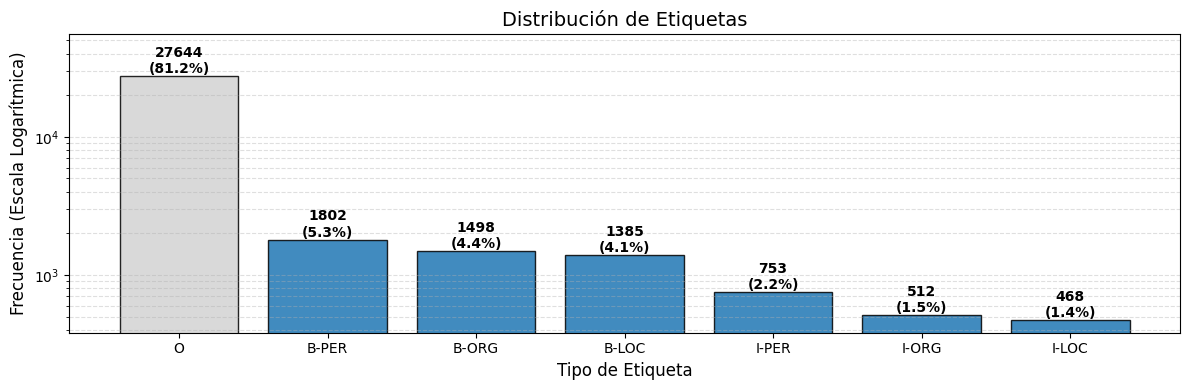

In [7]:
plt.figure(figsize=(12, 4))

colores = ['#d3d3d3' if tag == 'O' else '#1f77b4' for tag in etiquetas]
bars = plt.bar(etiquetas, valores, color=colores, edgecolor='black', alpha=0.85)

for bar in bars:
    height = bar.get_height()
    percentage = (height / total_tokens) * 100
    label_text = f'{int(height)}\n({percentage:.1f}%)'
    
    plt.text(bar.get_x() + bar.get_width() / 2,  
        height,                            
        label_text,                         
        ha='center',                        
        va='bottom',                        
        fontsize=10, 
        fontweight='bold',
        color='black')

plt.title(f'Distribución de Etiquetas', fontsize=14)
plt.xlabel('Tipo de Etiqueta', fontsize=12)
plt.ylabel('Frecuencia (Escala Logarítmica)', fontsize=12)
plt.yscale('log') 
plt.ylim(top=max(valores) * 2)
plt.grid(axis='y', linestyle='--', alpha=0.4, which='both')
plt.tight_layout()
plt.show()

## 3. Preprocesado del texto

### 3.1 Normalización y construcción de vocabulario

In [8]:
# Normalización suave
def limpiar_token(token):
    # Detectar menciones de twitter 
    if token.startswith('@') and len(token) > 1:
        return "<USR>"
    # Detectar URLs
    if token.startswith('http') or token.startswith('www.'):
        return "<URL>"
    # Números y mayúsculas sin procesar 
    return token 

# Limpieza a todo el corpus
oraciones_limpias = []
for oracion in oraciones:
    nueva_oracion = []
    for palabra, tag in oracion:
        palabra_limpia = limpiar_token(palabra)
        nueva_oracion.append((palabra_limpia, tag))
    oraciones_limpias.append(nueva_oracion)

# Tags 
unique_tags = list(set(tag for oracion in oraciones_limpias for palabra, tag in oracion))
unique_tags.sort()
tag2id = {tag: i for i, tag in enumerate(unique_tags)}
id2tag = {i: tag for tag, i in tag2id.items()}

# Vocabulario 
palabras_unicas = set(palabra for oracion in oraciones_limpias for palabra, tag in oracion)

# Tokens especiales
word2id = {"<PAD>": 0, "<UNK>": 1, "<USR>": 2, "<URL>": 3}
idx = 4
for palabra in palabras_unicas:
    if palabra not in word2id:
        word2id[palabra] = idx
        idx += 1

print(f"Tamaño del vocabulario: {len(word2id)}")
print(f"Ejemplo de tokens especiales: {word2id['<USR>']}, {word2id['<URL>']}")

Tamaño del vocabulario: 7858
Ejemplo de tokens especiales: 2, 3


### 3.2 Vectorización

In [9]:
MAX_LEN = 50
PAD_ID = word2id["<PAD>"]
TAG_PAD_ID = tag2id["O"]  

def vectorizar_oraciones(data, word2id, tag2id, max_len, tag_pad_value):
    X = []
    y = []
    
    for oracion in data:
        x_ids = [word2id.get(palabra, word2id["<UNK>"]) for palabra, tag in oracion]
        y_ids = [tag2id[tag] for palabra, tag in oracion]
        
        if len(x_ids) < max_len:
            padding_len = max_len - len(x_ids)
            x_ids = x_ids + [PAD_ID] * padding_len
            y_ids = y_ids + [tag_pad_value] * padding_len 
        else:
            x_ids = x_ids[:max_len]
            y_ids = y_ids[:max_len]
            
        X.append(x_ids)
        y.append(y_ids)
        
    return np.array(X), np.array(y)

In [10]:
X, y = vectorizar_oraciones(oraciones_limpias, word2id, tag2id, MAX_LEN, TAG_PAD_ID)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (2138, 50)
Forma de y: (2138, 50)


## 4. Modelado de redes bidireccionales con Keras

### 4.1 Setup (Semilla, GPU y splits)

Fijar semilla

In [11]:
def set_global_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_global_seed(42)

Configurar GPU

In [12]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

Divide X e y en train/validación/test con proporción 70/15/15.

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (1496, 50), Val: (321, 50), Test: (321, 50)


### 4.3 Dataloaders

In [14]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def crear_dataset(x_data, y_data, is_training=True):
    ds = tf.data.Dataset.from_tensor_slices((x_data, y_data))
    ds = ds.cache()
    if is_training:
        ds = ds.shuffle(buffer_size=len(x_data), seed=42, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

train_ds = crear_dataset(X_train, y_train, is_training=True)
val_ds   = crear_dataset(X_val, y_val, is_training=False)
test_ds  = crear_dataset(X_test, y_test, is_training=False)


### 4.4 Construcción de la red 

In [15]:
def crear_modelo(vocab_size, num_tags, max_len, embedding_dim=100,embedding_matrix=None,  trainable_embeddings=True, 
                        rnn_type='LSTM', rnn_units=32,num_rnn_layers=1,       
                        spatial_dropout=0.2, dense_dropout=0.5, l2_reg=1e-3, 
                        lr=0.001):

    model = models.Sequential(name=f"NER_{rnn_type}_L{num_rnn_layers}")

    # CAPA DE EMBEDDING
    if embedding_matrix is not None:
        # Embeddings Preentrenados
        vocab_size = embedding_matrix.shape[0]
        embedding_dim = embedding_matrix.shape[1]
        model.add(layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len, 
                                weights=[embedding_matrix], trainable=trainable_embeddings,      # entrenar o no pesos del embedding pre-entrenado
                                mask_zero=True, name='embedding_pretrain'))
    else:
        # Embedding propio
        model.add(layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                                input_length=max_len, mask_zero=True, 
                                name='embedding_scratch'))

    model.add(layers.SpatialDropout1D(spatial_dropout, name='spatial_dropout'))         # Dropout sobre embedding

    # CAPAS RECURRENTES LSTM/GRU y nº capas
    RecurrentLayer = layers.LSTM if rnn_type == 'LSTM' else layers.GRU
    
    for i in range(num_rnn_layers):
        model.add(layers.Bidirectional(
            RecurrentLayer(units=rnn_units, return_sequences=True,kernel_regularizer=regularizers.l2(l2_reg), recurrent_regularizer=regularizers.l2(l2_reg)),
            name=f'bidirectional_{rnn_type}_{i+1}'))
        model.add(layers.BatchNormalization(name=f'batch_norm_{i+1}'))           # BatchNormalization entre capas 

    # CAPA SALIDA
    model.add(layers.Dropout(dense_dropout, name='dropout_final'))
    model.add(layers.TimeDistributed(layers.Dense(num_tags, activation='softmax'), name='output'))

    # OPTIMIZADOR Y COMPILACIÓN
    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    
    return model

### 4.5 Definición de callbacks

#### 4.5.1 F1-score

In [16]:
class NER_F1_Callback(callbacks.Callback):
    def __init__(self, validation_data, id2tag, log_dir):
        super(NER_F1_Callback, self).__init__()
        self.X_val = validation_data[0]
        self.y_val = validation_data[1]
        self.id2tag = id2tag
        self.file_writer = tf.summary.create_file_writer(log_dir + '/metrics')
        
    def on_epoch_end(self, epoch, logs={}):
        val_pred_probs = self.model.predict(self.X_val, verbose=0)
        val_pred_ids = np.argmax(val_pred_probs, axis=-1)
        y_true_clean = []
        y_pred_clean = []
        
        for i in range(len(self.y_val)):
            for j in range(len(self.y_val[i])):
                true_id = self.y_val[i][j]
                if true_id != 0: 
                    y_true_clean.append(self.id2tag[true_id])
                    y_pred_clean.append(self.id2tag[val_pred_ids[i][j]])

        report = classification_report(y_true_clean, y_pred_clean, output_dict=True, zero_division=0)
        f1_macro = report['macro avg']['f1-score']
        print(f" - val_f1_macro: {f1_macro:.4f}")

        with self.file_writer.as_default():
            tf.summary.scalar('val_f1_macro', f1_macro, step=epoch)
        logs['val_f1'] = f1_macro

## 5. Iteraciones experimentales

### 5.1 Red 1: BiLSTM (1 capa - 32 neuronas - dropout medio - embedding propio)

In [17]:
nombre_experimento = "E01_BiLSTM_Base"
log_dir = os.path.join("logs", "fit", nombre_experimento + "_" + datetime.datetime.now().strftime("%H%M"))

f1_callback = NER_F1_Callback(validation_data=(X_val, y_val), id2tag=id2tag, log_dir=log_dir)

tensorboard_callback = callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

early_stopping = callbacks.EarlyStopping( monitor='val_loss', patience=5, restore_best_weights=True, verbose=1 )

reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1 )

mis_callbacks = [tensorboard_callback, early_stopping, reduce_lr, f1_callback]

model1= crear_modelo(vocab_size=len(word2id), num_tags=len(tag2id), max_len=MAX_LEN,
    rnn_type='LSTM',num_rnn_layers=1, rnn_units=32)

history1 = model1.fit(train_ds, epochs=50, validation_data=val_ds, callbacks=mis_callbacks)

Epoch 1/50
47/47 [==============================] - 19s 166ms/step - loss: 0.5028 - accuracy: 0.7484 - val_loss: 0.6757 - val_accuracy: 0.8228 - lr: 0.0010 - val_f1: 0.1685
Epoch 2/50
47/47 [==============================] - 2s 36ms/step - loss: 0.2720 - accuracy: 0.8584 - val_loss: 0.5750 - val_accuracy: 0.8249 - lr: 0.0010 - val_f1: 0.1808
Epoch 3/50
47/47 [==============================] - 2s 35ms/step - loss: 0.1722 - accuracy: 0.9000 - val_loss: 0.5029 - val_accuracy: 0.8294 - lr: 0.0010 - val_f1: 0.1905
Epoch 4/50
47/47 [==============================] - 2s 35ms/step - loss: 0.1167 - accuracy: 0.9345 - val_loss: 0.4372 - val_accuracy: 0.8500 - lr: 0.0010 - val_f1: 0.2806
Epoch 5/50
47/47 [==============================] - 2s 35ms/step - loss: 0.0844 - accuracy: 0.9601 - val_loss: 0.3814 - val_accuracy: 0.8767 - lr: 0.0010 - val_f1: 0.3889
Epoch 6/50
47/47 [==============================] - 2s 35ms/step - loss: 0.0671 - accuracy: 0.9700 - val_loss: 0.3245 - val_accuracy: 0.8886 - 

### 5.2 BiLSTM (1 capa - 32 neuronas - dropout medio - embedding preentrenado )

In [18]:
# fuente del embedding preentrenado -> https://www.kaggle.com/datasets/bertcarremans/glovetwitter27b100dtxt

def cargar_embedding_glove(ruta_archivo, word2id, embedding_dim=100):
    embeddings_index = {}
    with open(ruta_archivo, encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            try:
                coefs = np.asarray(values[1:], dtype='float32')
                embeddings_index[word] = coefs
            except ValueError:
                continue 
    embedding_matrix = np.random.normal(scale=0.6, size=(len(word2id), embedding_dim))
    embedding_matrix[0] = np.zeros(embedding_dim)

    hits = 0
    misses = 0
    for word, i in word2id.items():
        if i == 0: continue 
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
            hits += 1
        else:
            embedding_vector = embeddings_index.get(word.lower())
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector
                hits += 1
            else:
                misses += 1
                
    print(f"Conversión finalizada: {hits} palabras encontradas, {misses} ausentes (inicializadas aleatoriamente).")
    return embedding_matrix

In [ ]:
GLOVE_PATH = r"glove.twitter.27B.100d.txt"
EMBEDDING_DIM = 100

matriz_glove = cargar_embedding_glove(GLOVE_PATH, word2id, embedding_dim=EMBEDDING_DIM)

Conversión finalizada: 6734 palabras encontradas, 1123 ausentes (inicializadas aleatoriamente).


In [20]:
# limpieza memoria entre experimentos
tf.keras.backend.clear_session();gc.collect()

# Nombre exp y directorio nuevo
nombre_experimento = "E02_BiLSTM_glove50d" 
log_dir = os.path.join("logs", "fit", nombre_experimento + "_" + datetime.datetime.now().strftime("%H%M"))

# Reinstanciar callbacks para apuntar nuevo directorio 
f1_callback = NER_F1_Callback(validation_data=(X_val, y_val), id2tag=id2tag, log_dir=log_dir)

tensorboard_callback = callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

mis_callbacks = [tensorboard_callback, early_stopping, reduce_lr, f1_callback]

In [21]:
model2 = crear_modelo(vocab_size=len(word2id), num_tags=len(tag2id), max_len=MAX_LEN,
                    embedding_dim=EMBEDDING_DIM, embedding_matrix=matriz_glove, trainable_embeddings=True,         
                    rnn_type='LSTM', num_rnn_layers=1, rnn_units=32,dense_dropout=0.5)

history2 = model2.fit(train_ds, epochs=50, validation_data=val_ds, callbacks=mis_callbacks)

Epoch 1/50
47/47 [==============================] - 13s 136ms/step - loss: 0.8871 - accuracy: 0.5569 - val_loss: 0.5221 - val_accuracy: 0.8216 - lr: 0.0010 - val_f1: 0.1628
Epoch 2/50
47/47 [==============================] - 2s 35ms/step - loss: 0.4972 - accuracy: 0.7815 - val_loss: 0.4405 - val_accuracy: 0.8236 - lr: 0.0010 - val_f1: 0.0707
Epoch 3/50
47/47 [==============================] - 2s 36ms/step - loss: 0.4019 - accuracy: 0.8139 - val_loss: 0.3752 - val_accuracy: 0.8377 - lr: 0.0010 - val_f1: 0.1095
Epoch 4/50
47/47 [==============================] - 2s 35ms/step - loss: 0.3375 - accuracy: 0.8329 - val_loss: 0.3181 - val_accuracy: 0.8569 - lr: 0.0010 - val_f1: 0.1495
Epoch 5/50
47/47 [==============================] - 2s 35ms/step - loss: 0.2894 - accuracy: 0.8506 - val_loss: 0.2672 - val_accuracy: 0.8795 - lr: 0.0010 - val_f1: 0.2085
Epoch 6/50
47/47 [==============================] - 2s 35ms/step - loss: 0.2531 - accuracy: 0.8601 - val_loss: 0.2266 - val_accuracy: 0.8907 - 

### 5.3 BiLSTM (1 capa - 32 neuronas - dropout medio - embedding preentrenado - class weights )

In [22]:
# Definir pesos por etiqueta
# 'O' y 'PAD' tienen peso 1. Las entidades tienen peso 10.
weights_dict = {i: 10.0 for i in range(len(id2tag))}
weights_dict[tag2id['O']] = 1.0
weights_dict[0] = 0.0  

def generar_sample_weights(y_data, weights_dict):
    sample_weights = np.ones_like(y_data, dtype='float32')

    for i in range(len(y_data)):
        for j in range(len(y_data[i])):
            tag_id = y_data[i][j]
            sample_weights[i][j] = weights_dict.get(tag_id, 1.0)
            
    return sample_weights

train_sample_weights = generar_sample_weights(y_train, weights_dict)

In [23]:
def weighted_dataset(x_data, y_data, w_data, is_training=True):
    ds = tf.data.Dataset.from_tensor_slices((x_data, y_data, w_data))
    ds = ds.cache()
    if is_training:
        ds = ds.shuffle(buffer_size=len(x_data), seed=42, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

# Solo train con pesos, validation y test sin pesos
train_ds_weighted = weighted_dataset(X_train, y_train, train_sample_weights, is_training=True)

In [24]:
tf.keras.backend.clear_session(); gc.collect()

nombre_experimento = "E03_BiLSTM_GloVe100_WeightedLoss"
log_dir = os.path.join("logs", "fit", nombre_experimento + "_" + datetime.datetime.now().strftime("%H%M"))

f1_callback = NER_F1_Callback(validation_data=(X_val, y_val), id2tag=id2tag, log_dir=log_dir)
tensorboard_callback = callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
mis_callbacks = [tensorboard_callback, early_stopping, reduce_lr, f1_callback]

model3 = crear_modelo(vocab_size=len(word2id), num_tags=len(tag2id), max_len=MAX_LEN,
    embedding_dim=EMBEDDING_DIM, embedding_matrix=matriz_glove, trainable_embeddings=True,
    rnn_type='LSTM', num_rnn_layers=1, rnn_units=32 )


history3 = model3.fit(train_ds_weighted, epochs=50, validation_data=val_ds, callbacks=mis_callbacks)

Epoch 1/50
47/47 [==============================] - 14s 141ms/step - loss: 2.2506 - accuracy: 0.4400 - val_loss: 0.6595 - val_accuracy: 0.8408 - lr: 0.0010 - val_f1: 0.1778
Epoch 2/50
47/47 [==============================] - 2s 35ms/step - loss: 1.3762 - accuracy: 0.6216 - val_loss: 0.5987 - val_accuracy: 0.8583 - lr: 0.0010 - val_f1: 0.2862
Epoch 3/50
47/47 [==============================] - 2s 39ms/step - loss: 1.1383 - accuracy: 0.6839 - val_loss: 0.5495 - val_accuracy: 0.8647 - lr: 0.0010 - val_f1: 0.3674
Epoch 4/50
47/47 [==============================] - 2s 37ms/step - loss: 1.0152 - accuracy: 0.7229 - val_loss: 0.4948 - val_accuracy: 0.8738 - lr: 0.0010 - val_f1: 0.4318
Epoch 5/50
47/47 [==============================] - 2s 35ms/step - loss: 0.8967 - accuracy: 0.7547 - val_loss: 0.4597 - val_accuracy: 0.8729 - lr: 0.0010 - val_f1: 0.4609
Epoch 6/50
47/47 [==============================] - 2s 36ms/step - loss: 0.8078 - accuracy: 0.7767 - val_loss: 0.4168 - val_accuracy: 0.8820 - 

### 5.4  BiGRU (1 capa - 32 neuronas - dropout medio - embedding preentrenado - class weights)

In [25]:
tf.keras.backend.clear_session(); gc.collect()

nombre_experimento = "E04_BiGRU_GloVe100_WeightedLoss"
log_dir = os.path.join("logs", "fit", nombre_experimento + "_" + datetime.datetime.now().strftime("%H%M"))

f1_callback = NER_F1_Callback(validation_data=(X_val, y_val), id2tag=id2tag, log_dir=log_dir)
tensorboard_callback = callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
mis_callbacks = [tensorboard_callback, early_stopping, reduce_lr, f1_callback]

model4 = crear_modelo(vocab_size=len(word2id), num_tags=len(tag2id), max_len=MAX_LEN,
                    embedding_dim=EMBEDDING_DIM, embedding_matrix=matriz_glove,trainable_embeddings=True,
                    rnn_type='GRU',num_rnn_layers=1,rnn_units=32,    
                    spatial_dropout=0.2,dense_dropout=0.5 )

history4 = model4.fit(train_ds_weighted, epochs=50, validation_data=val_ds, callbacks=mis_callbacks)

Epoch 1/50
47/47 [==============================] - 13s 131ms/step - loss: 2.2980 - accuracy: 0.4054 - val_loss: 0.5728 - val_accuracy: 0.8139 - lr: 0.0010 - val_f1: 0.2219
Epoch 2/50
47/47 [==============================] - 2s 36ms/step - loss: 1.4455 - accuracy: 0.6024 - val_loss: 0.5022 - val_accuracy: 0.8403 - lr: 0.0010 - val_f1: 0.3426
Epoch 3/50
47/47 [==============================] - 2s 35ms/step - loss: 1.1820 - accuracy: 0.6595 - val_loss: 0.4253 - val_accuracy: 0.8653 - lr: 0.0010 - val_f1: 0.4073
Epoch 4/50
47/47 [==============================] - 2s 34ms/step - loss: 1.0145 - accuracy: 0.7086 - val_loss: 0.3954 - val_accuracy: 0.8635 - lr: 0.0010 - val_f1: 0.4409
Epoch 5/50
47/47 [==============================] - 2s 35ms/step - loss: 0.8964 - accuracy: 0.7470 - val_loss: 0.3672 - val_accuracy: 0.8725 - lr: 0.0010 - val_f1: 0.4911
Epoch 6/50
47/47 [==============================] - 2s 34ms/step - loss: 0.8353 - accuracy: 0.7616 - val_loss: 0.3513 - val_accuracy: 0.8721 - 

### 5.5 BiGRU (2 capas - 64/32 neuronas - dropout medio - embedding preentrenado - class weights)

In [26]:
tf.keras.backend.clear_session();gc.collect()

nombre_experimento = "E05_BiGRU_2L_64u_Weighted"
log_dir = os.path.join("logs", "fit", nombre_experimento + "_" + datetime.datetime.now().strftime("%H%M"))

f1_callback = NER_F1_Callback(validation_data=(X_val, y_val), id2tag=id2tag, log_dir=log_dir)
tensorboard_callback = callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
mis_callbacks = [tensorboard_callback, early_stopping, reduce_lr, f1_callback]

model5 = crear_modelo(vocab_size=len(word2id), num_tags=len(tag2id), max_len=MAX_LEN,
                    embedding_dim=EMBEDDING_DIM, embedding_matrix=matriz_glove, trainable_embeddings=True,
                    rnn_type='GRU', num_rnn_layers=2, rnn_units=64, 
                    spatial_dropout=0.3, dense_dropout=0.5, l2_reg=1e-4 )       #ligero ajuste de dropout

history5 = model5.fit(train_ds_weighted, epochs=50, validation_data=val_ds, callbacks=mis_callbacks)

Epoch 1/50
47/47 [==============================] - 24s 229ms/step - loss: 2.0130 - accuracy: 0.4792 - val_loss: 0.3629 - val_accuracy: 0.8527 - lr: 0.0010 - val_f1: 0.1793
Epoch 2/50
47/47 [==============================] - 3s 65ms/step - loss: 1.2295 - accuracy: 0.6459 - val_loss: 0.3023 - val_accuracy: 0.8672 - lr: 0.0010 - val_f1: 0.3027
Epoch 3/50
47/47 [==============================] - 3s 54ms/step - loss: 0.9799 - accuracy: 0.7111 - val_loss: 0.2846 - val_accuracy: 0.8742 - lr: 0.0010 - val_f1: 0.4165
Epoch 4/50
47/47 [==============================] - 2s 53ms/step - loss: 0.8250 - accuracy: 0.7367 - val_loss: 0.2682 - val_accuracy: 0.8746 - lr: 0.0010 - val_f1: 0.4743
Epoch 5/50
47/47 [==============================] - 3s 54ms/step - loss: 0.6999 - accuracy: 0.7648 - val_loss: 0.2684 - val_accuracy: 0.8766 - lr: 0.0010 - val_f1: 0.5038
Epoch 6/50
46/47 [============================>.] - ETA: 0s - loss: 0.6255 - accuracy: 0.7882
Epoch 6: ReduceLROnPlateau reducing learning rate

### 5.6 BiGRU (1 capas - 64 neuronas - dropout alto - embedding preentrenado - class weights)

In [27]:
tf.keras.backend.clear_session(); gc.collect()

nombre_experimento = "E06_BiGRU_1L_64u_HighDrop" 
log_dir = os.path.join("logs", "fit", nombre_experimento + "_" + datetime.datetime.now().strftime("%H%M"))

f1_callback = NER_F1_Callback(validation_data=(X_val, y_val), id2tag=id2tag, log_dir=log_dir)
tensorboard_callback = callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
mis_callbacks = [tensorboard_callback, early_stopping, reduce_lr, f1_callback]

model6 = crear_modelo(vocab_size=len(word2id), num_tags=len(tag2id), max_len=MAX_LEN,
                    embedding_dim=EMBEDDING_DIM, embedding_matrix=matriz_glove, trainable_embeddings=True,
                    rnn_type='GRU', num_rnn_layers=1, rnn_units=64,
                    spatial_dropout=0.35, dense_dropout=0.7,l2_reg=1e-4 )

history6 = model6.fit(train_ds_weighted, epochs=50, validation_data=val_ds, callbacks=mis_callbacks)

Epoch 1/50
47/47 [==============================] - 13s 128ms/step - loss: 2.4931 - accuracy: 0.4099 - val_loss: 0.3286 - val_accuracy: 0.8461 - lr: 0.0010 - val_f1: 0.2090
Epoch 2/50
47/47 [==============================] - 2s 35ms/step - loss: 1.6074 - accuracy: 0.5643 - val_loss: 0.2906 - val_accuracy: 0.8527 - lr: 0.0010 - val_f1: 0.3385
Epoch 3/50
47/47 [==============================] - 2s 35ms/step - loss: 1.2930 - accuracy: 0.6226 - val_loss: 0.2555 - val_accuracy: 0.8593 - lr: 0.0010 - val_f1: 0.3589
Epoch 4/50
47/47 [==============================] - 2s 34ms/step - loss: 1.1200 - accuracy: 0.6585 - val_loss: 0.2527 - val_accuracy: 0.8564 - lr: 0.0010 - val_f1: 0.4301
Epoch 5/50
47/47 [==============================] - 2s 35ms/step - loss: 0.9344 - accuracy: 0.6872 - val_loss: 0.2395 - val_accuracy: 0.8634 - lr: 0.0010 - val_f1: 0.4653
Epoch 6/50
47/47 [==============================] - 2s 34ms/step - loss: 0.8109 - accuracy: 0.7212 - val_loss: 0.2297 - val_accuracy: 0.8694 - 

### 5.7 BiGRU (1 capa - 32 neuronas - dropout medio - embedding preentrenado - CRF)

In [28]:
def modelo_crf(vocab_size, num_tags, max_len, embedding_matrix):
    inputs = layers.Input(shape=(max_len,), dtype='int32')
    x = layers.Embedding(input_dim=vocab_size, output_dim=100, 
                        input_length=max_len, weights=[embedding_matrix], 
                        trainable=True, mask_zero=True)(inputs)
    
    x = layers.SpatialDropout1D(0.2)(x)

    x = layers.Bidirectional(layers.GRU(units=32, return_sequences=True, kernel_regularizer=regularizers.l2(1e-3)))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.TimeDistributed(layers.Dense(num_tags, activation='linear'))(x)
    base_model = models.Model(inputs, outputs)
    model = CRFModel(base_model, units=num_tags)
    
    return model

In [29]:
class NER_F1_Callback_CRF(callbacks.Callback):
    def __init__(self, validation_data, id2tag, log_dir):
        super(NER_F1_Callback_CRF, self).__init__()
        self.X_val = validation_data[0]
        self.y_val = validation_data[1]
        self.id2tag = id2tag
        self.file_writer = tf.summary.create_file_writer(log_dir + '/metrics')
        
    def on_epoch_end(self, epoch, logs={}):
        val_pred = self.model.predict(self.X_val, verbose=0)
        if len(val_pred) != len(self.y_val):
            try:
                flat_pred = []
                for batch in val_pred:
                    flat_pred.extend(batch)
                val_pred = flat_pred
            except Exception:
                pass

        y_true_clean = []
        y_pred_clean = []
        for true_labels, raw_pred in zip(self.y_val, val_pred):
            pred_labels = np.array(raw_pred).flatten().astype(int)

            limit = min(len(true_labels), len(pred_labels))
            
            for j in range(limit):
                true_id = true_labels[j]
                pred_id = pred_labels[j]
                
                if true_id != 0: 
                    try:
                        y_true_clean.append(self.id2tag[true_id])
                        y_pred_clean.append(self.id2tag[pred_id])
                    except KeyError:
                        pass
        try:
            report = classification_report(y_true_clean, y_pred_clean, output_dict=True, zero_division=0)
            f1_macro = report['macro avg']['f1-score']
            print(f" - val_f1_macro: {f1_macro:.4f}")
            with self.file_writer.as_default():
                tf.summary.scalar('val_f1_macro', f1_macro, step=epoch)
                
            logs['val_f1'] = f1_macro
            
        except Exception as e:
            print(f" - Error calculando F1: {e}")

In [30]:
tf.keras.backend.clear_session();gc.collect()

nombre_experimento = "E07_BiGRU_32u_CRF"
log_dir = os.path.join("logs", "fit", nombre_experimento + "_" + datetime.datetime.now().strftime("%H%M"))

f1_callback = NER_F1_Callback_CRF(validation_data=(X_val, y_val), id2tag=id2tag, log_dir=log_dir)
tensorboard_callback = callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
mis_callbacks = [tensorboard_callback, early_stopping, reduce_lr, f1_callback]

model7= modelo_crf(len(word2id), len(tag2id), MAX_LEN, matriz_glove)

model7.compile(optimizer=optimizers.Adam(learning_rate=0.001))

history7 = model7.fit(train_ds, epochs=50, validation_data=val_ds, callbacks=mis_callbacks)

Epoch 1/50
47/47 [==============================] - 22s 291ms/step - loss: 28.8229 - val_loss: 14.8440 - lr: 0.0010 - val_f1: 0.1414
Epoch 2/50
47/47 [==============================] - 10s 209ms/step - loss: 14.3901 - val_loss: 11.7872 - lr: 0.0010 - val_f1: 0.2155
Epoch 3/50
47/47 [==============================] - 10s 215ms/step - loss: 11.2964 - val_loss: 9.2852 - lr: 0.0010 - val_f1: 0.2508
Epoch 4/50
47/47 [==============================] - 10s 207ms/step - loss: 9.6209 - val_loss: 7.5673 - lr: 0.0010 - val_f1: 0.2986
Epoch 5/50
47/47 [==============================] - 10s 204ms/step - loss: 8.1585 - val_loss: 6.1904 - lr: 0.0010 - val_f1: 0.3252
Epoch 6/50
47/47 [==============================] - 10s 208ms/step - loss: 7.4003 - val_loss: 5.0244 - lr: 0.0010 - val_f1: 0.3681
Epoch 7/50
47/47 [==============================] - 10s 206ms/step - loss: 6.4912 - val_loss: 5.0938 - lr: 0.0010 - val_f1: 0.4221
Epoch 8/50
47/47 [==============================] - 10s 205ms/step - loss: 6.0

### 5.8 Modelo híbrido -> BiGRU + CNN char (1 capa- 64 neuronas - dropout medio - embedding preentrenado)

In [31]:
MAX_CHAR_LEN = 15  
chars = set([c for w in word2id.keys() for c in w])
char2id = {c: i + 2 for i, c in enumerate(chars)}
char2id["<PAD>"] = 0
char2id["<UNK>"] = 1

# Función para vectorizar caracteres
def get_char_seq(sentences, max_len, max_char_len):
    X_char = []
    for sentence in sentences:
        sent_seq = []
        for i in range(max_len):
            word_seq = []
            if i < len(sentence):
                pass 
            sent_seq.append(word_seq)
        X_char.append(sent_seq)
    return np.array(X_char)

def vectorizar_chars(data, char2id, max_len, max_char_len):
    X_char = np.zeros((len(data), max_len, max_char_len), dtype='int32')
    for i, oracion in enumerate(data):
        for j, (palabra, tag) in enumerate(oracion):
            if j >= max_len: break
            for k, char in enumerate(palabra):
                if k >= max_char_len: break
                X_char[i, j, k] = char2id.get(char, char2id["<UNK>"])       
    return X_char


id2word = {v: k for k, v in word2id.items()}
def recuperar_texto_y_vectorizar_chars(X_ids, id2word, char2id, max_len, max_char_len):
    X_char = np.zeros((len(X_ids), max_len, max_char_len), dtype='int32')
    for i, seq_ids in enumerate(X_ids):
        for j, word_id in enumerate(seq_ids):
            if word_id == 0: continue
            word = id2word.get(word_id, "<UNK>")
            for k, char in enumerate(word):
                if k >= max_char_len: break
                X_char[i, j, k] = char2id.get(char, char2id["<UNK>"])
    return X_char

X_train_char = recuperar_texto_y_vectorizar_chars(X_train, id2word, char2id, MAX_LEN, MAX_CHAR_LEN)
X_val_char   = recuperar_texto_y_vectorizar_chars(X_val, id2word, char2id, MAX_LEN, MAX_CHAR_LEN)
# X_test_char  = ... (test final)

In [32]:
def dataset_multi_input(x_word, x_char, y_data, is_training=True):
    ds = tf.data.Dataset.from_tensor_slices((
        {"input_word": x_word, "input_char": x_char}, y_data))
    ds = ds.cache()
    if is_training:
        ds = ds.shuffle(buffer_size=len(x_word), seed=42)
    ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_multi = dataset_multi_input(X_train, X_train_char, y_train, is_training=True)
val_ds_multi   = dataset_multi_input(X_val, X_val_char, y_val, is_training=False)

In [33]:
def modelo_hibrido_crf(vocab_size, char_vocab_size, num_tags, max_len, max_char_len, embedding_matrix):
    input_word = layers.Input(shape=(max_len,), name="input_word", dtype='int32')
    emb_word = layers.Embedding(input_dim=vocab_size, output_dim=100,
                            weights=[embedding_matrix], trainable=True, mask_zero=True)(input_word)
    emb_word = layers.SpatialDropout1D(0.2)(emb_word)
    
    # --- RAMA CARACTERES ---
    input_char = layers.Input(shape=(max_len, max_char_len), name="input_char", dtype='int32')
    
    # Embedding de caracteres desde cero
    emb_char = layers.TimeDistributed(layers.Embedding(input_dim=char_vocab_size, output_dim=30))(input_char)
    
    # CNN de caracteres para extraer formas
    char_cnn = layers.TimeDistributed(layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'))(emb_char)
    char_cnn = layers.TimeDistributed(layers.MaxPooling1D(pool_size=max_char_len))(char_cnn)
    char_cnn = layers.TimeDistributed(layers.Flatten())(char_cnn) 
    char_cnn = layers.Dropout(0.2)(char_cnn)

    # --- FUSIÓN glove con CNN
    x = layers.Concatenate()([emb_word, char_cnn])
    
    x = layers.Bidirectional(layers.GRU(units=64, return_sequences=True,
                                    kernel_regularizer=regularizers.l2(1e-4)))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.TimeDistributed(layers.Dense(num_tags, activation='linear'))(x)
    base_model = models.Model(inputs=[input_word, input_char], outputs=outputs)
    model = CRFModel(base_model, units=num_tags)
    return model

In [34]:
tf.keras.backend.clear_session(); gc.collect()

nombre_experimento = "E08_Hybrid_CharCNN_BiGRU_CRF"
log_dir = os.path.join("logs", "fit", nombre_experimento + "_" + datetime.datetime.now().strftime("%H%M"))


f1_callback = NER_F1_Callback_CRF(validation_data=([X_val, X_val_char], y_val), id2tag=id2tag, log_dir=log_dir)
tensorboard_callback = callbacks.TensorBoard(log_dir=log_dir)
mis_callbacks = [tensorboard_callback, early_stopping, reduce_lr, f1_callback]

model8 = modelo_hibrido_crf(vocab_size=len(word2id),char_vocab_size=len(char2id),num_tags=len(tag2id),
                        max_len=MAX_LEN,max_char_len=MAX_CHAR_LEN,embedding_matrix=matriz_glove)

model8.compile(optimizer=optimizers.Adam(0.001))
history8 = model8.fit(train_ds_multi,epochs=50,validation_data=val_ds_multi,callbacks=mis_callbacks)

Epoch 1/50
47/47 [==============================] - 28s 345ms/step - loss: 24.0912 - val_loss: 9.1893 - lr: 0.0010 - val_f1: 0.1372
Epoch 2/50
47/47 [==============================] - 11s 232ms/step - loss: 12.3207 - val_loss: 7.4764 - lr: 0.0010 - val_f1: 0.1968
Epoch 3/50
47/47 [==============================] - 11s 235ms/step - loss: 9.3868 - val_loss: 6.7471 - lr: 0.0010 - val_f1: 0.2521
Epoch 4/50
47/47 [==============================] - 11s 238ms/step - loss: 7.8470 - val_loss: 5.6880 - lr: 0.0010 - val_f1: 0.3635
Epoch 5/50
47/47 [==============================] - 12s 257ms/step - loss: 6.5641 - val_loss: 5.3920 - lr: 0.0010 - val_f1: 0.4354
Epoch 6/50
47/47 [==============================] - 12s 257ms/step - loss: 5.7397 - val_loss: 4.5318 - lr: 0.0010 - val_f1: 0.4978
Epoch 7/50
47/47 [==============================] - 12s 256ms/step - loss: 4.9825 - val_loss: 4.3703 - lr: 0.0010 - val_f1: 0.5053
Epoch 8/50
47/47 [==============================] - 12s 255ms/step - loss: 4.4840

### 5.9 Modelo híbrido -> BiGRU + CNN char (1 capa- 64 neuronas - dropout medio - embedding preentrenado - data augmentation)

In [35]:
def get_chars(X_ids, word2id, max_len=MAX_LEN, max_char_len=15):
    id2word = {v: k for k, v in word2id.items()}
    chars = set([c for w in word2id.keys() for c in w])
    char2id = {c: i + 2 for i, c in enumerate(chars)}
    char2id["<PAD>"] = 0; char2id["<UNK>"] = 1
    
    out = np.zeros((len(X_ids), max_len, max_char_len), dtype='int32')
    for i, seq in enumerate(X_ids):
        for j, wid in enumerate(seq):
            if wid == 0: continue
            w = id2word.get(wid, "UNK")
            for k, c in enumerate(w):
                if k < max_char_len: 
                    out[i,j,k] = char2id.get(c, 1) 
    return out, len(char2id)

def create_dual_ds(xw, xc, y, train=True):
    data = tf.data.Dataset.from_tensor_slices(({"input_word": xw, "input_char": xc}, y))
    if train: 
        data = data.shuffle(len(xw), seed=42)
    return data.batch(32).prefetch(tf.data.AUTOTUNE)

def augment_entity_swap(X, y, id2tag, p=0.5):
    X_aug, y_aug = [], []
    candidates = {}
    
    # 1. Buscar candidatos
    for i in range(len(y)):
        for j in range(len(y[i])):
            tag_id = y[i][j]
            if tag_id == 0: continue
            if id2tag[tag_id] != 'O': 
                if tag_id not in candidates: candidates[tag_id] = []
                candidates[tag_id].append(X[i][j])
    
    for i in range(len(X)):
        X_aug.append(X[i]) 
        y_aug.append(y[i])
        
        if np.random.rand() < p:
            new_seq = X[i].copy()
            changed = False
            for j in range(len(new_seq)):
                tag_id = y[i][j]
                if tag_id in candidates and len(candidates[tag_id]) > 1:
                    new_seq[j] = np.random.choice(candidates[tag_id])
                    changed = True
            if changed:
                X_aug.append(new_seq)
                y_aug.append(y[i])
                
    return np.array(X_aug), np.array(y_aug)

In [36]:
X_train_aug, y_train_aug = augment_entity_swap(X_train, y_train, id2tag, p=0.5)

X_train_char_aug, num_chars = get_chars(X_train_aug, word2id)
X_val_char, _ = get_chars(X_val, word2id) 

train_ds_aug = create_dual_ds(X_train_aug, X_train_char_aug, y_train_aug, train=True)
val_ds_h = create_dual_ds(X_val, X_val_char, y_val, train=False)

In [37]:
tf.keras.backend.clear_session(); gc.collect()

nombre_experimento = "E09_Hybrid_Augmentation"
log_dir = os.path.join("logs", "fit", nombre_experimento + "_" + datetime.datetime.now().strftime("%H%M"))

f1_callback = NER_F1_Callback_CRF(validation_data=([X_val, X_val_char], y_val), id2tag=id2tag, log_dir=log_dir)
tensorboard_callback = callbacks.TensorBoard(log_dir=log_dir)
mis_callbacks = [tensorboard_callback, early_stopping, reduce_lr, f1_callback]

model9 = modelo_hibrido_crf(vocab_size=len(word2id),
    char_vocab_size=num_chars, num_tags=len(tag2id),max_len=MAX_LEN,            
    max_char_len=15,embedding_matrix=matriz_glove )

model9.compile(optimizer=optimizers.Adam(0.001))

history9 = model9.fit(train_ds_aug,epochs=50,validation_data=val_ds_h,callbacks=mis_callbacks)

Epoch 1/50
66/66 [==============================] - 29s 301ms/step - loss: 17.1878 - val_loss: 12.8536 - lr: 0.0010 - val_f1: 0.1490
Epoch 2/50
66/66 [==============================] - 14s 219ms/step - loss: 9.0711 - val_loss: 9.5228 - lr: 0.0010 - val_f1: 0.3035
Epoch 3/50
66/66 [==============================] - 15s 230ms/step - loss: 7.0575 - val_loss: 6.7937 - lr: 0.0010 - val_f1: 0.3828
Epoch 4/50
66/66 [==============================] - 16s 240ms/step - loss: 5.4778 - val_loss: 5.7924 - lr: 0.0010 - val_f1: 0.5005
Epoch 5/50
66/66 [==============================] - 16s 240ms/step - loss: 4.7931 - val_loss: 3.4266 - lr: 0.0010 - val_f1: 0.5401
Epoch 6/50
66/66 [==============================] - 16s 244ms/step - loss: 4.0160 - val_loss: 2.3766 - lr: 0.0010 - val_f1: 0.5517
Epoch 7/50
66/66 [==============================] - 16s 239ms/step - loss: 3.4840 - val_loss: 2.0350 - lr: 0.0010 - val_f1: 0.5661
Epoch 8/50
66/66 [==============================] - 16s 242ms/step - loss: 3.1025

## 6. Evaluación resultados

### 6.1 Comparación entre todos los modelos (tensorboard)

In [45]:
# %load_ext tensorboard
# %tensorboard --logdir logs/fit

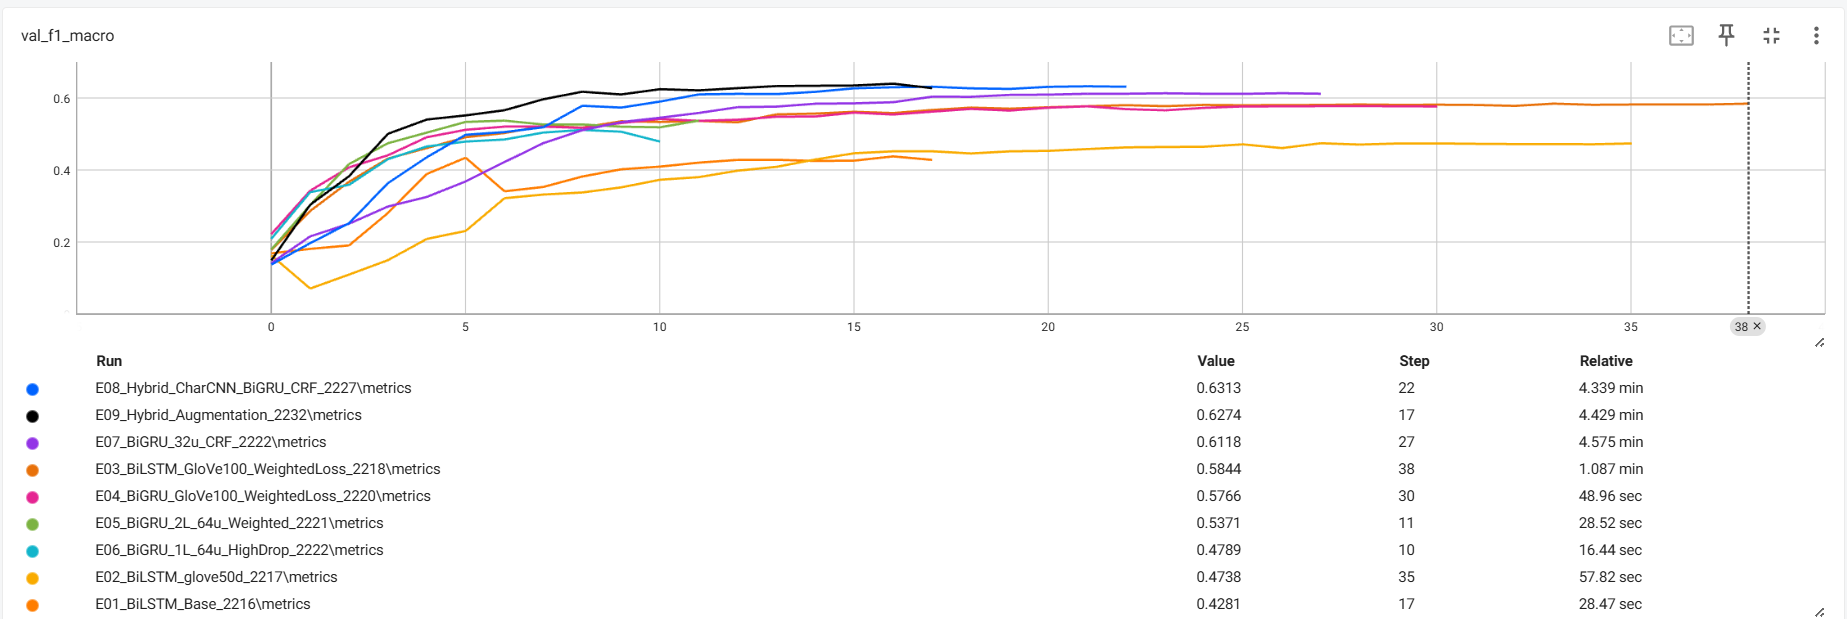

### 6.1 Gráficos de evolución modelo nº8

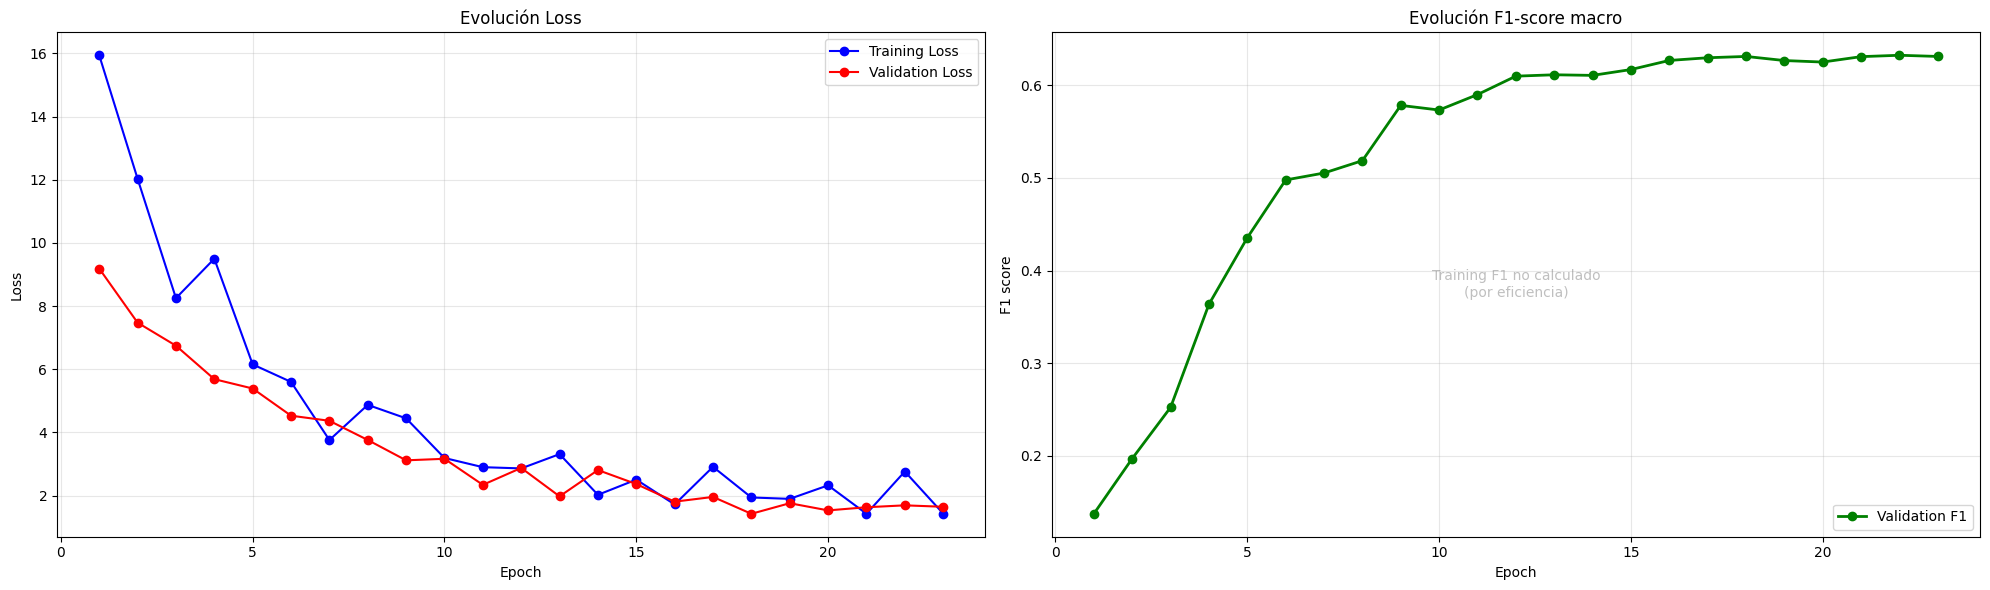

In [38]:
loss = history8.history.get('loss', [])
val_loss = history8.history.get('val_loss', [])
val_f1 = history8.history.get('val_f1_macro', history8.history.get('val_f1', []))
train_f1 = history8.history.get('f1_macro', history8.history.get('f1', [])) 

epochs_range = range(1, len(loss) + 1)
plt.figure(figsize=(20, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, 'b-o', label='Training Loss')
plt.plot(epochs_range, val_loss, 'r-o', label='Validation Loss')
plt.title('Evolución Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)

if val_f1:
    plt.plot(epochs_range, val_f1, 'g-o', label='Validation F1', linewidth=2)
if train_f1:
    plt.plot(epochs_range, train_f1, 'b--o', label='Training F1', alpha=0.6)
else:
    plt.text(0.5, 0.5, 'Training F1 no calculado\n(por eficiencia)', 
            horizontalalignment='center', verticalalignment='center', 
            transform=plt.gca().transAxes, color='gray', alpha=0.5)

plt.title('Evolución F1-score macro')
plt.xlabel('Epoch')
plt.ylabel('F1 score')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 Matriz de confusión modelo nº8

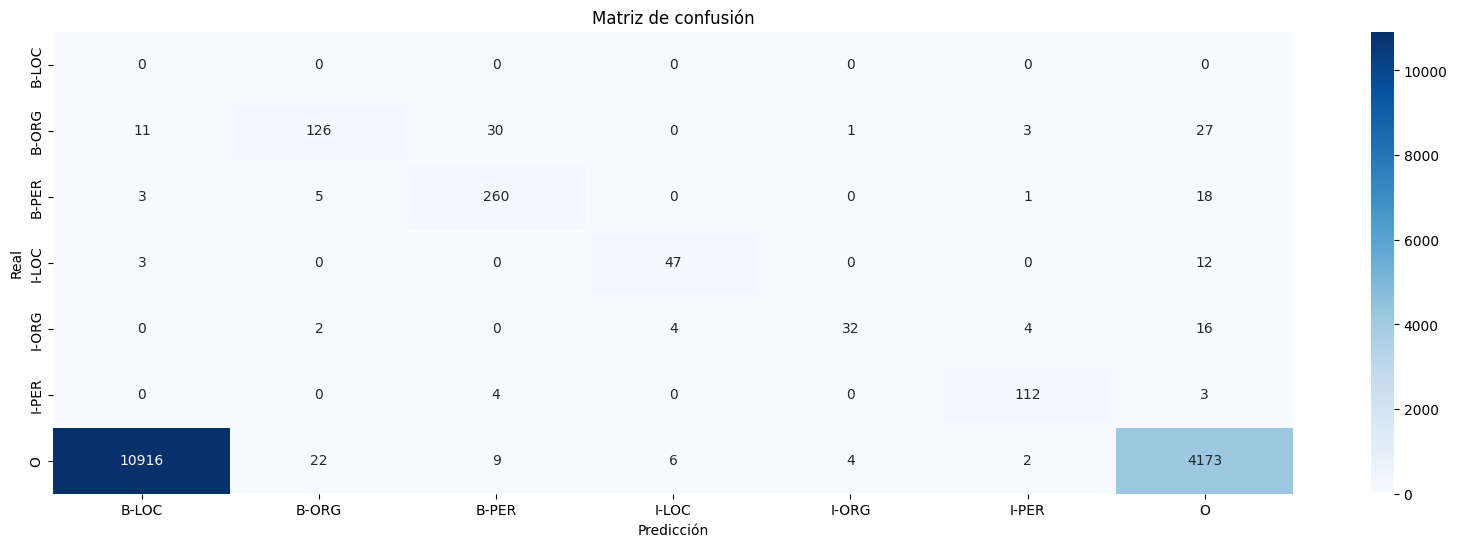

In [39]:
y_pred_raw = model8.predict([X_val, X_val_char],verbose=0)

if len(y_pred_raw) != len(y_val):
    temp_pred = []
    for batch in y_pred_raw: temp_pred.extend(batch)
    y_pred_raw = temp_pred

true_flat, pred_flat = [], []

for i in range(len(y_val)):
    true_seq = y_val[i]
    pred_seq = np.array(y_pred_raw[i]).flatten().astype(int)
    limit = min(len(true_seq), len(pred_seq))
    
    for j in range(limit):
        t_id = true_seq[j]
        p_id = pred_seq[j]
        if t_id == 0: continue
        tag_true = id2tag[t_id]
        tag_pred = id2tag[p_id]
        true_flat.append(tag_true)
        pred_flat.append(tag_pred)

labels = sorted(list(set(true_flat + pred_flat)))
if 'O' in labels: 
    labels.remove('O')
    labels.append('O')

cm = confusion_matrix(true_flat, pred_flat, labels=labels)
plt.figure(figsize=(20, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión')
plt.show()

### 6.3 Ejemplo de predicción sobre set de validación modelo nº8

In [40]:
idx = np.random.randint(0, len(X_val)) 
sample_in = X_val[idx]
sample_true = y_val[idx]

pred_raw =  model8.predict([X_val, X_val_char],verbose=0)
pred_ids = np.array(pred_raw[0]).flatten().astype(int)

id2word = {v: k for k, v in word2id.items()}
print(f"\n--- EJEMPLO DE PREDICCIÓN ---")
print(f"{'PALABRA':<15} | {'REAL':<10} | {'PREDICCIÓN':<10}")
print("-" * 45)

for i in range(len(sample_in)):
    wid = sample_in[i]
    if wid == 0: break 
    word = id2word.get(wid, "UNK")
    t_tag = id2tag.get(sample_true[i], "?")
    p_tag = id2tag.get(pred_ids[i], "?") if i < len(pred_ids) else "N/A"
    marker = "✅" if t_tag == p_tag else "❌"
    if t_tag != p_tag:
        print(f"\033[91m{word:<15} | {t_tag:<10} | {p_tag:<10} {marker}\033[0m")
    else:
        print(f"{word:<15} | {t_tag:<10} | {p_tag:<10} {marker}")


--- EJEMPLO DE PREDICCIÓN ---
PALABRA         | REAL       | PREDICCIÓN
---------------------------------------------
First           | O          | O          ✅
lorries         | O          | O          ✅
from            | O          | O          ✅
controversial   | O          | O          ✅
Russian         | B-LOC      | O          ❌
aid             | O          | B-PER      ❌
convoy          | O          | I-PER      ❌
leave           | O          | O          ✅
rebel-held      | O          | O          ✅
eastern         | B-LOC      | O          ❌
Ukraine         | I-LOC      | B-LOC      ❌
-               | O          | B-LOC      ❌
witnesses       | O          | B-LOC      ❌
<URL>           | O          | B-LOC      ❌


# 7. Conclusiones

## 7.1 Contexto
El proyecto abordó la tarea de **Reconocimiento de Entidades Nombradas (NER)** en un entorno crítico caracterizado por:

*   **Escasez de datos:** Solo ~2,000 muestras de entrenamiento (Broad Twitter Corpus).
*   **Alto ruido:** Texto informal, jerga, errores ortográficos y menciones no estándar.
*   **Desbalance de clases:** Predominancia masiva de la etiqueta 'O' (no entidad).

---

## 7.2 Mejor modelo: arquitectura híbrida
Tras probar 9 configuraciones experimentales, el modelo ganador fue el **Experimento 5.8: Modelo Híbrido (BiGRU + Char-CNN + CRF)**. Esta arquitectura superó a los baselines gracias a su diseño tripartito:

*   **Embeddings de palabras (GloVe):** Aportaron **semántica general** pre-entrenada.
*   **CNN de caracteres:** Permitió identificar **entidades desconocidas o mal escritas** basándose en su **morfología** (prefijos, sufijos, mayúsculas), crucial para el texto de Twitter.
*   **Capa CRF:** Impuso **restricciones lógicas** en las secuencias de etiquetas ("I-PER no puede ir tras O"), corrigiendo incoherencias.

---

## 7.3 resultados cuantitativos
Hubo un progreso sustancial en la métrica objetivo, el f1-score macro:

*   **Baseline BiLSTM simple:** ~0.42
*   **Modelo híbrido (nº8)** preferible si se premia la **precisión:** ~0.64 (**+52%** de mejora relativa frente baseline)
*   **Modelo básico (nº4)** preferible si se premia la **latencia :** ~0.58
*   **Data Augmentation:** ~0.62 (ligera degradación).

---

## 7.4 Hallazgo principal
> **"En escenarios de escasez de datos, con texto ruidoso, la morfología (caracteres) aporta más valor que la sintaxis artificial (data augmentation)."**

*   **Aumentar datos mediante *Entity Swapping* fue contraproducente**. Al carecer de un modelo de lenguaje profundo para validar el contexto, introdujo **"alucinaciones"** (falsos positivos).
*   **CNN de caracteres efectiva:** Añadir una rama de convolución de caracteres permitió al **modelo generalizar mejor** sobre el vocabulario existente sin introducir ruido. Fue la estrategia más eficiente costo-beneficio.

---

## 7.5 Futuros posibles pasos 
*   **Escenario con recursos limitados:** Se recomienda el **modelo 5.8**.
*   **Para superar el techo (F1 ~0.64):** La evidencia sugiere **aumentar la recopilación de datos para alimentar mejor al modelo** (*garbage in, garbage out*). El orden de prioridad sería:
    1.  **Invertir en la recolección de más datos etiquetados** de calidad.
    2.  **Volver a iterar con redes más anchas o profundas** para validar si existe mejor captación de patrones subyacentes con mayor nº de datos
    3.  **Transicionar a arquitecturas basadas en Transformers** (ej: BERTweet) **si el cómputo y coste lo permite**.